In [1]:
import re
import json
import numpy as np
import matplotlib.pyplot as plt

from spacy.lang.de import German
import os
from tqdm import tqdm
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import json
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from datetime import datetime
from ipywidgets import interact, fixed
import glob
import os
from scipy.sparse import csr_matrix, vstack
from tqdm import tqdm
from collections import defaultdict

In [2]:

def load_text_from_file(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)
    out_text = ''
    for speech in data:
        out_text+= speech['text']
    return out_text


In [3]:

all_files = glob.glob(os.path.join('./data/opendata_api/parsed_protocols', "*.json"))
text_list = []
for i, file in enumerate(tqdm(all_files)):
    text_list.append((file[-15:-5], load_text_from_file(file)))
   

  0%|          | 0/2065 [00:00<?, ?it/s]

100%|██████████| 2065/2065 [00:29<00:00, 69.55it/s]


In [9]:
years = range(1991,2025)
grouped_years = {str(year):[] for year in years}
for date_str, text in text_list:
    year = str(datetime.strptime(date_str,'%Y-%m-%d' ).year)
    grouped_years[year].append((date_str, text))
    print(f"appended ({date_str}, {text[:10]}) to grouped_years{year}")


appended (1991-03-12, Frau Präsi) to grouped_years1991
appended (1991-03-13, Sehr vereh) to grouped_years1991
appended (1991-03-14, Frau
Präsi) to grouped_years1991
appended (1991-03-15, Gerne, Her) to grouped_years1991
appended (1991-03-20, Herr Präsi) to grouped_years1991
appended (1991-03-21, Frau Präsi) to grouped_years1991
appended (1991-03-22, Herr Präsi) to grouped_years1991
appended (1991-04-17, Frau Präsi) to grouped_years1991
appended (1991-04-18, Frau
Präsi) to grouped_years1991
appended (1991-04-19, Herr Präsi) to grouped_years1991
appended (1991-04-25, Frau Präsi) to grouped_years1991
appended (1991-04-26, Herr Präsi) to grouped_years1991
appended (1991-05-14, Frau Präsi) to grouped_years1991
appended (1991-06-04, Herr Präsi) to grouped_years1991
appended (1991-06-05, Frau Präsi) to grouped_years1991
appended (1991-06-06, Frau Präsi) to grouped_years1991
appended (1991-06-07, Herr Präsi) to grouped_years1991
appended (1991-06-12, Verehrte K) to grouped_years1991
appended (

In [10]:
#print(grouped_years['2019'][1][:20])

print(np.array(grouped_years['1991']).shape)

(56, 2)


In [13]:
all_speeches = ''
for date, protocol in grouped_years[str(years[0])]:
        all_speeches+=protocol

In [33]:
counts_for_years =  {str(year):[] for year in years}
for year in tqdm(years):
    vectorizer = CountVectorizer()
    all_speeches = ''
    for date, protocol in grouped_years[str(year)]:
        all_speeches+=protocol
    count_matrix = vectorizer.fit_transform([all_speeches])
    count_array = count_matrix.toarray()
    word_counts = count_array[0]
    feature_names = vectorizer.get_feature_names_out()
    word_count_pairs = list(zip(feature_names, word_counts))
    counts_for_years[str(year)] = word_count_pairs

100%|██████████| 34/34 [01:51<00:00,  3.29s/it]


In [25]:
vectorizer = CountVectorizer()
all_speeches_2019 = ''
for date, protocol in grouped_years['2022']:
    all_speeches_2019+=protocol


# Fit and transform the documents to a count matrix
count_matrix = vectorizer.fit_transform([all_speeches_2019])

# Get the feature names (words)
feature_names = vectorizer.get_feature_names_out()


# Convert the count matrix to an array
count_array = count_matrix.toarray()

word_counts = count_array[0]

# Create a list of (word, count) tuples
word_count_pairs = list(zip(feature_names, word_counts))

# Sort the list by count in descending order
sorted_word_count_pairs = sorted(word_count_pairs, key=lambda x: x[1], reverse=True)
sorted_word_count_pairs[:20]

[('der', 182456),
 ('die', 167661),
 ('und', 160864),
 ('das', 91957),
 ('wir', 86951),
 ('in', 80517),
 ('ist', 69028),
 ('sie', 67127),
 ('bei', 64583),
 ('es', 53240),
 ('nicht', 52148),
 ('auch', 51053),
 ('den', 49950),
 ('zu', 48786),
 ('dass', 43566),
 ('für', 42901),
 ('ich', 39889),
 ('von', 38153),
 ('beifall', 37372),
 ('haben', 37175)]

In [34]:
def get_counts(token, word_count_pairs):
    for entry in word_count_pairs:
        if entry[0] == token:
            return entry[1]


In [35]:
def get_timecounts_for_token(token):
    word_timevector = []
    for key, word_count_pairs in counts_for_years.items():
        word_timevector.append(get_counts(token, word_count_pairs))
    return word_timevector

In [47]:
outarr = get_timecounts_for_token('dumm')

In [40]:
import seaborn as sns

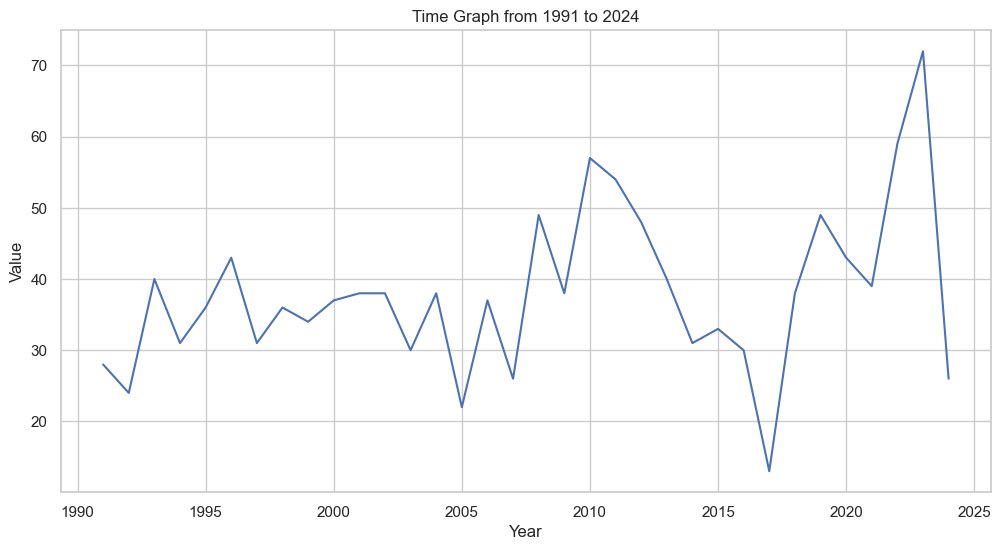

In [49]:
data = pd.DataFrame({'Year': years, 'Value': outarr})

# Set the aesthetics for the plot
sns.set(style='whitegrid')

# Create the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Value', data=data)

# Add titles and labels
plt.title('Time Graph from 1991 to 2024')
plt.xlabel('Year')
plt.ylabel('Value')

# Show the plot
plt.show()

In [52]:
print(counts_for_years.keys())

dict_keys(['1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024'])


In [5]:
vectorizer = CountVectorizer()

In [15]:
# Fit and transform the documents to a count matrix
count_matrix = vectorizer.fit_transform([grouped_years['2014'][0][1]])

# Get the feature names (words)
feature_names = vectorizer.get_feature_names_out()


# Convert the count matrix to an array
count_array = count_matrix.toarray()

word_counts = count_array[0]

# Create a list of (word, count) tuples
word_count_pairs = list(zip(feature_names, word_counts))

# Sort the list by count in descending order
sorted_word_count_pairs = sorted(word_count_pairs, key=lambda x: x[1], reverse=True)
sorted_word_count_pairs[:20]

[('die', 862),
 ('der', 777),
 ('und', 600),
 ('das', 433),
 ('in', 427),
 ('ist', 356),
 ('wir', 332),
 ('dass', 329),
 ('ich', 317),
 ('zu', 307),
 ('es', 299),
 ('nicht', 298),
 ('sie', 291),
 ('auch', 285),
 ('den', 258),
 ('im', 229),
 ('von', 217),
 ('des', 207),
 ('für', 191),
 ('mit', 191)]

In [2]:
with open('./data/test/20_113_2023-06-23.txt', encoding='utf8') as f:
    doc = f.read()


In [3]:
print(doc)

Plenarprotokoll 20/113

Deutscher Bundestag
Stenografischer Bericht

113. Sitzung

Berlin, Freitag, den 23. Juni 2023



Inhalt:

Erweiterung der Tagesordnung



Zusatzpunkt 5:

– Zweite und dritte Beratung des von der Bundesregierung eingebrachten Entwurfs eines Gesetzes zur Weiterentwicklung der Fachkräfteeinwanderung


Drucksachen 20/6500, 20/6946, 20/7293 Nr. 1.3, 20/7394



– Bericht des Haushaltsausschusses gemäß § 96 der Geschäftsordnung


Drucksache 20/7406




in Verbindung mit


Zusatzpunkt 6:

Beschlussempfehlung und Bericht des Ausschusses für Arbeit und Soziales zu dem Antrag der Abgeordneten René Springer, Jürgen Pohl, Gerrit Huy, weiterer Abgeordneter und der Fraktion der AfD: Technisierung statt Zuwanderung – Für einen Arbeitsmarkt der Zukunft


Drucksachen 20/5225, 20/7409 Buchstabe b)




Nancy Faeser, Bundesministerin BMI




Andrea Lindholz (CDU/CSU)




Dr. Konstantin von Notz (GRÜNE)




Norbert Kleinwächter (AfD)




Johannes Vogel (FDP)




Gökay Akbulut (DIE LI

In [4]:
vectorizer = CountVectorizer()
 
vectorizer.fit([doc])

CountVectorizer()

In [5]:

vector = vectorizer.transform([doc])

In [6]:
vectorizer.vocabulary_

{'plenarprotokoll': 7614,
 '20': 44,
 '113': 7,
 'deutscher': 2425,
 'bundestag': 2103,
 'stenografischer': 9111,
 'bericht': 1623,
 'sitzung': 8781,
 'berlin': 1635,
 'freitag': 3831,
 'den': 2374,
 '23': 72,
 'juni': 5581,
 '2023': 63,
 'inhalt': 5319,
 'erweiterung': 3351,
 'der': 2385,
 'tagesordnung': 9362,
 'zusatzpunkt': 11345,
 'zweite': 11406,
 'und': 9720,
 'dritte': 2562,
 'beratung': 1599,
 'des': 2399,
 'von': 10412,
 'bundesregierung': 2100,
 'eingebrachten': 2768,
 'entwurfs': 3143,
 'eines': 2748,
 'gesetzes': 4382,
 'zur': 11285,
 'weiterentwicklung': 10706,
 'fachkräfteeinwanderung': 3495,
 'drucksachen': 2584,
 '6500': 152,
 '6946': 165,
 '7293': 173,
 'nr': 7291,
 '7394': 187,
 'haushaltsausschusses': 4855,
 'gemäß': 4205,
 '96': 224,
 'geschäftsordnung': 4352,
 'drucksache': 2583,
 '7406': 198,
 'in': 5261,
 'verbindung': 9949,
 'mit': 6847,
 'beschlussempfehlung': 1685,
 'ausschusses': 1216,
 'für': 3948,
 'arbeit': 795,
 'soziales': 8866,
 'zu': 11208,
 'dem': 23